In [1]:
import pickle
import numpy as np
# import casadi as ca
from timeit import default_timer as timer
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pyswarms.single.global_best import GlobalBestPSO
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from util import *
# from BayesOpt import *
from BayesOpt_torch import *
from myGP_torch import *
from examples.ex_fcn import *
import warnings
import logging
logging.disable(logging.CRITICAL)

#suppress warnings
warnings.filterwarnings('ignore')

# An example to test contextual Bayesian optimization

This is an example with 2 optimization variables and 4 contexts

In [2]:
class quadratic(blackbox_fcn):
    def __init__(self):
        super().__init__()
        
    def evaluate_true(self, Z, T):
        z1, z2 = Z
        t1, t2, t3, t4 = T
        obj = (z1 - (2*t1+3*t2))**2 + (z2 - (4*t3-t4))**2 + (z1-z2)**2
        noise = np.random.normal(0, 0.01)
        return -obj + noise

In [3]:
# Bounds on the inputs variable
n_pts = 101
var_bounds = [(-5., 10.), (0., 15.)]
# Bounds on the context variable
ctx_bounds = [(-5., 5.), (-3., 3.), (-5., 5.), (-3., 3.)]
true_fcn = quadratic()
training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 5}
CBO = Context_BayesOpt(2, 4, print_level=True, training_params=training_params)
CBO.set_feasible_set(var_bounds, ctx_bounds, n_pts)

In [4]:
OUTCOME = CBO.run_Outer(true_fcn, k_max = 30, k_init = 5, j_max = 30, j_init = 5, beta = 1e2, beta_rate=0.9, tol=1e-1, patience=3)

Iteration # 1
Sample the context: [-1.3   2.76  4.3   1.02]
Bayes Opt proposes to sample  [-3.5 14.4]
Bayes Opt proposes to sample  [7.9 4.2]
Bayes Opt proposes to sample  [ 2.5  12.15]
Bayes Opt proposes to sample  [8.35 0.75]
Bayes Opt proposes to sample  [ 6.85 10.5 ]
Bayes Opt proposes to sample  [-5.  0.]
Bayes Opt proposes to sample  [10. 15.]
Bayes Opt proposes to sample  [1.94120314 0.        ]
Bayes Opt proposes to sample  [ 5.6694752 15.       ]
Bayes Opt proposes to sample  [10.         10.63054875]
Bayes Opt proposes to sample  [10. 15.]
Bayes Opt proposes to sample  [10.         11.34943216]
Bayes Opt proposes to sample  [ 7.12037316 10.95260237]
Bayes Opt proposes to sample  [10. 15.]
Bayes Opt proposes to sample  [10.         11.84733038]
Bayes Opt proposes to sample  [ 7.69338916 11.8335433 ]
Bayes Opt proposes to sample  [10.         12.30338803]
Bayes Opt proposes to sample  [ 7.84919926 12.04325456]
Bayes Opt proposes to sample  [ 8.042825   12.17271639]
Bayes Opt pr

In [5]:
CBO.GP_s.training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 5}
CBO.GP_s._train_gp(CBO.GP_s.X, CBO.GP_s.Y)

# Ground-truth from a solver

In [7]:
# # Using differential evolution and L-BFGS-B optimizer from SciPy, quite expensive
# from scipy.optimize import differential_evolution
# sample_T = CBO.TT
# best_Zsol = []

# for T in sample_T:
#     def obj(Z):
#         return -true_fcn.evaluate_true(Z, T)
#     # First global optimization
#     result_de = differential_evolution(obj, var_bounds)
#     # Then local refinement
#     res = minimize(obj, result_de.x, method='L-BFGS-B', bounds=var_bounds)
#     best_Zsol.append(res.x)

# best_Zsol = np.array(best_Zsol)

In [12]:
# Second option: using PSO optimizer
best_Zsol = []
# Test with random 100 samples
idx = np.random.randint(0, CBO.TT.shape[0], 100)
sample_T = CBO.TT[idx,:]
Z_GP, _ = CBO.GP_s.predict(sample_T)


In [7]:
# instantiate the optimizer
x_max = CBO.ZZ[-1]
x_min = CBO.ZZ[0]
bounds = (x_min, x_max)
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

for T in sample_T:
    # Define objective function for given T
    def objective(Z_particles):
        return -np.array([true_fcn.evaluate_true(Z, T).item() for Z in Z_particles])
    
    # Optimize with PSO
    optimizer = GlobalBestPSO(n_particles=30, dimensions=2, options=options, bounds=bounds)
    cost, pos = optimizer.optimize(objective, iters=100, verbose=False)
    # Add local refinement
    def single_obj(Z):
        return -true_fcn.evaluate_true(Z, T).item()

    res = minimize(single_obj, pos, method='L-BFGS-B', bounds=list(zip(x_min, x_max)))
    best_Zsol.append(res.x)

best_Zsol = np.array(best_Zsol)

### Plots for comparison

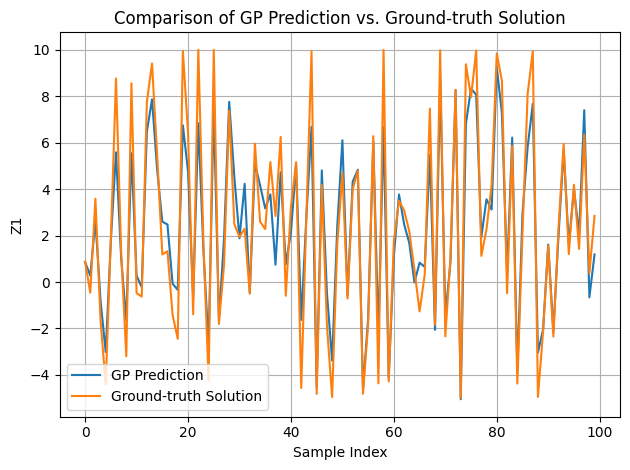

In [10]:
plt.plot(Z_GP[:, 0], label='GP Prediction')
plt.plot(best_Zsol[:, 0], label='Ground-truth Solution')
plt.xlabel('Sample Index')# 
plt.ylabel('Z1')
plt.title('Comparison of GP Prediction vs. Ground-truth Solution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


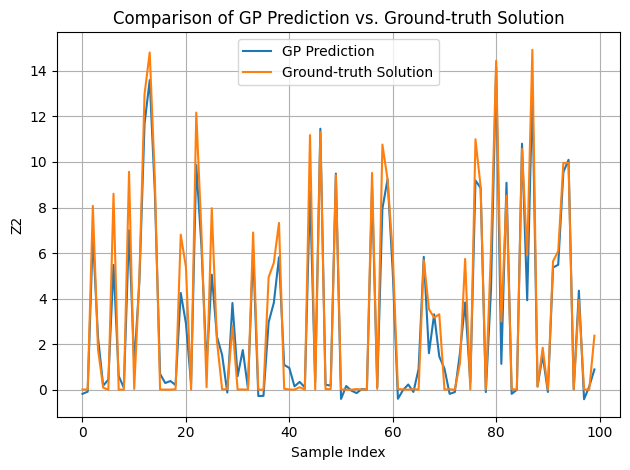

In [11]:
plt.plot(Z_GP[:, 1], label='GP Prediction')
plt.plot(best_Zsol[:, 1], label='Ground-truth Solution')
plt.xlabel('Sample Index')
plt.ylabel('Z2') 
plt.title('Comparison of GP Prediction vs. Ground-truth Solution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

